# Zadanie 2

## Importy

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import time
from pathlib import Path
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import fbeta_score, make_scorer, confusion_matrix, classification_report, brier_score_loss
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, GradientBoostingClassifier
from sklearn.preprocessing import LabelEncoder

## EDA + Preprocessing


In [13]:
column_names = [
    'class', 'cap-shape', 'cap-surface', 'cap-color', 'bruises', 'odor',
    'gill-attachment', 'gill-spacing', 'gill-size', 'gill-color',
    'stalk-shape', 'stalk-root', 'stalk-surface-above-ring',
    'stalk-surface-below-ring', 'stalk-color-above-ring',
    'stalk-color-below-ring', 'veil-type', 'veil-color', 'ring-number',
    'ring-type', 'spore-print-color', 'population', 'habitat'
]

data_dir = Path("..") / "data"
df = pd.read_csv(data_dir / 'agaricus-lepiota.data', header=None, names=column_names)

print(df.shape)

(8124, 23)


In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   class                     8124 non-null   str  
 1   cap-shape                 8124 non-null   str  
 2   cap-surface               8124 non-null   str  
 3   cap-color                 8124 non-null   str  
 4   bruises                   8124 non-null   str  
 5   odor                      8124 non-null   str  
 6   gill-attachment           8124 non-null   str  
 7   gill-spacing              8124 non-null   str  
 8   gill-size                 8124 non-null   str  
 9   gill-color                8124 non-null   str  
 10  stalk-shape               8124 non-null   str  
 11  stalk-root                8124 non-null   str  
 12  stalk-surface-above-ring  8124 non-null   str  
 13  stalk-surface-below-ring  8124 non-null   str  
 14  stalk-color-above-ring    8124 non-null   str  
 15

In [16]:
df.head()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


In [15]:
df.describe()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
count,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,...,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124
unique,2,6,4,10,2,9,2,2,2,12,...,4,9,9,1,4,3,5,9,6,7
top,e,x,y,n,f,n,f,c,b,b,...,s,w,w,p,w,o,p,w,v,d
freq,4208,3656,3244,2284,4748,3528,7914,6812,5612,1728,...,4936,4464,4384,8124,7924,7488,3968,2388,4040,3148


Widzimy że kolumna veil-type posiada tylko jedną wartość więc można tę kolumnę usunąć

In [39]:
df.drop('veil-type', axis=1)

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-above-ring,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,s,w,w,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,s,w,w,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,s,w,w,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,s,w,w,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,s,w,w,w,o,e,n,a,g
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8119,e,k,s,n,f,n,a,c,b,y,...,s,s,o,o,o,o,p,b,c,l
8120,e,x,s,n,f,n,a,c,b,y,...,s,s,o,o,n,o,p,b,v,l
8121,e,f,s,n,f,n,a,c,b,n,...,s,s,o,o,o,o,p,b,c,l
8122,p,k,y,n,f,y,f,c,n,b,...,s,k,w,w,w,o,e,w,v,l


In [40]:
missing = (df['stalk-root'] == '?').sum()
print(f"Liczba wierszy z brakiem danych ('?') w 'stalk-root': {missing} ({(missing/len(df))*100:.2f}%)")

Liczba wierszy z brakiem danych ('?') w 'stalk-root': 2480 (30.53%)


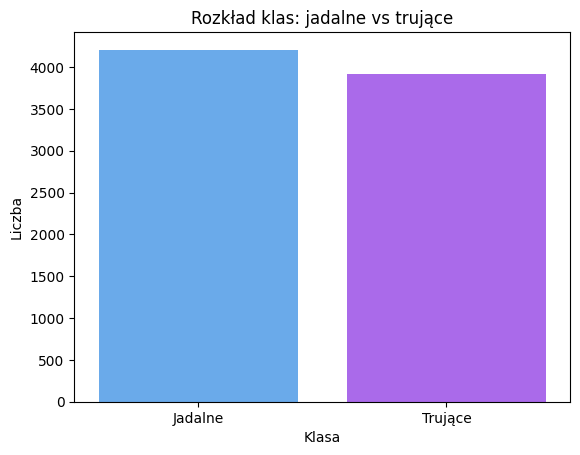

In [41]:
counts = df['class'].value_counts()

sns.barplot(x=counts.index, y=counts.values, hue=counts.index, palette="cool")
plt.title("Rozkład klas: jadalne vs trujące")
plt.xlabel("Klasa")
plt.ylabel("Liczba")
plt.xticks([0, 1], ["Jadalne", "Trujące"])
plt.show()

Klasy są zbalansowane więc mopżemy użyć do oceny modelu miary f2_score lub f1_score

In [42]:
df_encoded = df.drop('veil-type', axis=1).copy()

label_mappings = {}
le = LabelEncoder()

for col in df_encoded.columns:
    df_encoded[col] = le.fit_transform(df_encoded[col])
    
    mapping = dict(zip(le.classes_, le.transform(le.classes_)))
    label_mappings[col] = mapping

df_encoded.head(5)

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-above-ring,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,1,5,2,4,1,6,1,0,1,4,...,2,2,7,7,2,1,4,2,3,5
1,0,5,2,9,1,0,1,0,0,4,...,2,2,7,7,2,1,4,3,2,1
2,0,0,2,8,1,3,1,0,0,5,...,2,2,7,7,2,1,4,3,2,3
3,1,5,3,8,1,6,1,0,1,5,...,2,2,7,7,2,1,4,2,3,5
4,0,5,2,3,0,5,1,1,0,4,...,2,2,7,7,2,1,0,3,0,1


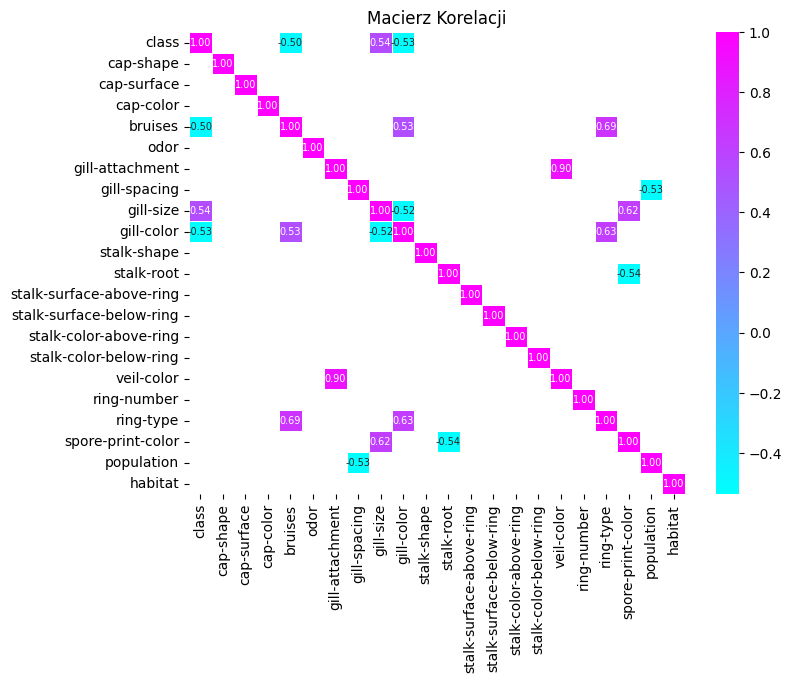

In [46]:
df_corr = df_encoded.copy()
corr = df_corr.corr()

mask_target_weak = (corr >= -0.5) & (corr <= 0.5)

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, mask=mask_target_weak, cmap="cool", fmt=".2f", linewidths=0.5, annot_kws={"size": 7})
plt.title("Macierz Korelacji")
plt.show()

Widzimy korelację na poziomie 0.9 cech gill-attachment z veil-color więc usuwamy jedną z nich

In [48]:
df_encoded.drop("gill-attachment", axis=1)

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-spacing,gill-size,gill-color,stalk-shape,...,stalk-surface-above-ring,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,1,5,2,4,1,6,0,1,4,0,...,2,2,7,7,2,1,4,2,3,5
1,0,5,2,9,1,0,0,0,4,0,...,2,2,7,7,2,1,4,3,2,1
2,0,0,2,8,1,3,0,0,5,0,...,2,2,7,7,2,1,4,3,2,3
3,1,5,3,8,1,6,0,1,5,0,...,2,2,7,7,2,1,4,2,3,5
4,0,5,2,3,0,5,1,0,4,1,...,2,2,7,7,2,1,0,3,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8119,0,3,2,4,0,5,0,0,11,0,...,2,2,5,5,1,1,4,0,1,2
8120,0,5,2,4,0,5,0,0,11,0,...,2,2,5,5,0,1,4,0,4,2
8121,0,2,2,4,0,5,0,0,5,0,...,2,2,5,5,1,1,4,0,1,2
8122,1,3,3,4,0,8,0,1,0,1,...,2,1,7,7,2,1,0,7,4,2


## Podział na zbiór treningowy i testowy

In [49]:
y = df_encoded["class"]
X = df_encoded.drop("class", axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

## Custom Scorer

In [50]:
f2_score = make_scorer(fbeta_score, beta = 2)

## Drzewo decyzyjne

In [54]:
tree = DecisionTreeClassifier(random_state=42)

param_grid_tree = {
    'max_depth': [3, 5, 10, 15, 20],
    'ccp_alpha': [0.0, 0.001, 0.01, 0.1],
    'class_weight': [None, 'balanced', {0: 1, 1: 5}, {0: 1, 1: 25}]
}

In [55]:
grid_search_tree = GridSearchCV(estimator=tree, param_grid=param_grid_tree, scoring=f2_score, n_jobs=-2)
grid_search_tree.fit(X_train, y_train)
print(f"Najlepsze parametry: {grid_search_tree.best_params_}")

Najlepsze parametry: {'ccp_alpha': 0.0, 'class_weight': None, 'max_depth': 10}


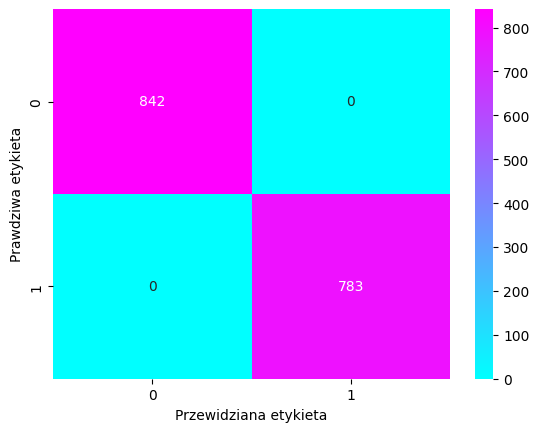

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       842
           1       1.00      1.00      1.00       783

    accuracy                           1.00      1625
   macro avg       1.00      1.00      1.00      1625
weighted avg       1.00      1.00      1.00      1625

f2_score: 1.0


In [56]:
best_tree = grid_search_tree.best_estimator_
y_pred_tree = best_tree.predict(X_test)

cm_tree = confusion_matrix(y_true=y_test, y_pred=y_pred_tree)
sns.heatmap(cm_tree, annot=True, fmt='d', cmap="cool")
plt.ylabel('Prawdziwa etykieta')
plt.xlabel('Przewidziana etykieta')
plt.show()

print(classification_report(y_true=y_test, y_pred=y_pred_tree))
print(f"f2_score: {fbeta_score(y_true=y_test, y_pred=y_pred_tree, beta=2)}")

## BaggingClassifier z płytkimi drzewami

In [57]:
param_grid_bagging = {
    'n_estimators': [5, 10, 15, 25, 50],
    'bootstrap': [True, False],
    'bootstrap_features': [True, False]
}

In [58]:
deep_tree = DecisionTreeClassifier(max_depth=15, random_state=42)
bagging_deep = BaggingClassifier(estimator=deep_tree, random_state=42)

grid_search_bagging_deep = GridSearchCV(estimator=bagging_deep, param_grid=param_grid_bagging, cv=5, scoring=f2_score, n_jobs=-1)
grid_search_bagging_deep.fit(X_train, y_train)
print(f"Najlepsze parametry: {grid_search_bagging_deep.best_params_}")

Najlepsze parametry: {'bootstrap': True, 'bootstrap_features': True, 'n_estimators': 5}


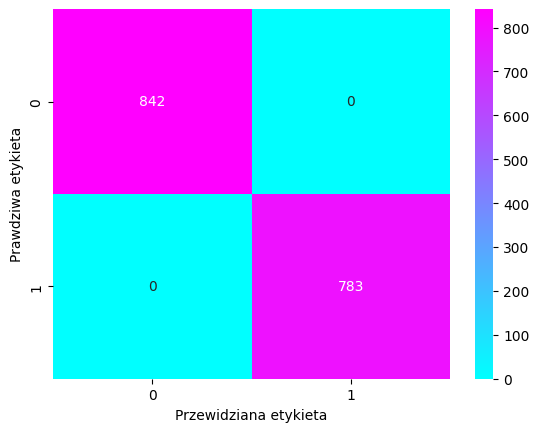

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       842
           1       1.00      1.00      1.00       783

    accuracy                           1.00      1625
   macro avg       1.00      1.00      1.00      1625
weighted avg       1.00      1.00      1.00      1625

f2_score: 1.0


In [59]:
best_bagging_deep = grid_search_bagging_deep.best_estimator_
y_pred_bagging_deep = best_bagging_deep.predict(X_test)

cm_bagging_deep = confusion_matrix(y_true=y_test, y_pred=y_pred_bagging_deep)
sns.heatmap(cm_bagging_deep, annot=True, fmt='d', cmap="cool")
plt.ylabel('Prawdziwa etykieta')
plt.xlabel('Przewidziana etykieta')
plt.show()

print(classification_report(y_true=y_test, y_pred=y_pred_bagging_deep))
print(f"f2_score: {fbeta_score(y_true=y_test, y_pred=y_pred_bagging_deep, beta=2)}")

## GradientBoostingClassifier

In [60]:
gbc = GradientBoostingClassifier(random_state=42)

param_grid_gbc = {
    'n_estimators': [25, 50, 100, 200, 300],
    'learning_rate': [0.01, 0.1, 0.5, 1.0],
    'max_depth': [3]
}

grid_search_gbc = GridSearchCV(estimator=gbc, param_grid=param_grid_gbc, cv=5, scoring=f2_score, n_jobs=-1)
grid_search_gbc.fit(X_train, y_train)
print(f"Najlepsze parametry: {grid_search_gbc.best_params_}")

Najlepsze parametry: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}


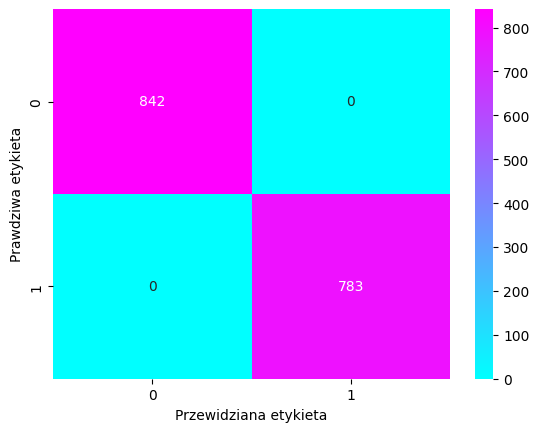

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       842
           1       1.00      1.00      1.00       783

    accuracy                           1.00      1625
   macro avg       1.00      1.00      1.00      1625
weighted avg       1.00      1.00      1.00      1625

f2_score: 1.0


In [61]:
best_gbc = grid_search_gbc.best_estimator_
y_pred_gbc = best_gbc.predict(X_test)

cm_gbc = confusion_matrix(y_true=y_test, y_pred=y_pred_gbc)
sns.heatmap(cm_gbc, annot=True, fmt='d', cmap="cool")
plt.ylabel('Prawdziwa etykieta')
plt.xlabel('Przewidziana etykieta')
plt.show()

print(classification_report(y_true=y_test, y_pred=y_pred_gbc))
print(f"f2_score: {fbeta_score(y_true=y_test, y_pred=y_pred_gbc, beta=2)}")

## Ewaluacja modeli

In [62]:
models_to_evaluate = {
    'Decision Tree': best_tree,
    'Bagging (Deep)': best_bagging_deep,
    'Gradient Boosting': best_gbc
}

time_results = {}

for name, model in models_to_evaluate.items():
    start_time = time.perf_counter()
    model.predict(X_test)
    end_time = time.perf_counter()
    time_results[name] = end_time - start_time

predict_results = {}

for name, model in models_to_evaluate.items():
    probabilities = model.predict_proba(X_test)
    prob_positive = probabilities[:, 1]
    brier = brier_score_loss(y_test, prob_positive)
    predict_results[name] = brier

Text(0.5, 1.0, 'Ocena pewności modelu (brier score) (mniej = lepiej)')

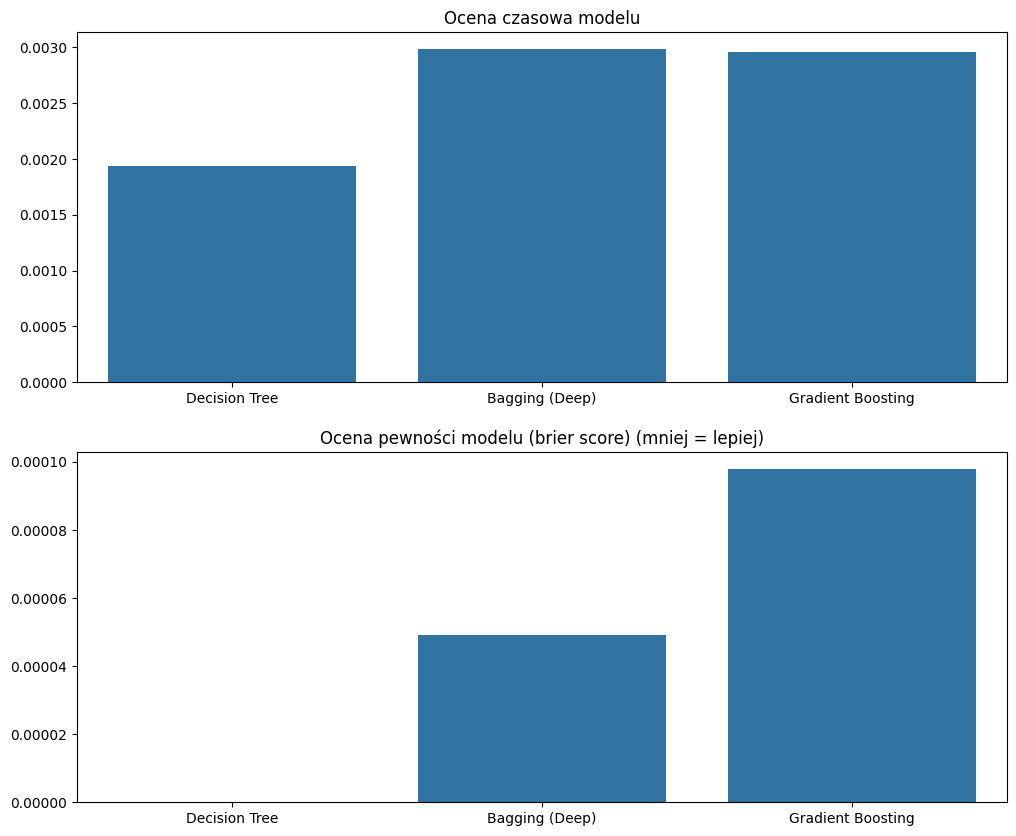

In [63]:
fig, axes = plt.subplots(2, 1, figsize=(12, 10))
sns.barplot(data=time_results, ax=axes[0])
axes[0].set_title("Ocena czasowa modelu")
sns.barplot(data=predict_results, ax=axes[1])
axes[1].set_title("Ocena pewności modelu (brier score) (mniej = lepiej)")

Wybieram drzewo decyzyjne, ponieważ ma ono 100% pewność przy wyborze oraz ma najkrótszy czas klasyfikacji i jest whiteboxem